# 📧 Comparative Evaluation of Transformer Models for Intelligent Email Routing


### Natural Language Processing – Large Language Models

**University:** University of Verona  
**Academic Year:** 2025–2026  
**Instructor:** Prof. Alberto Castellini  
**Student:** Finhas Demissie Bekele
**Student ID:** VR546999

---

> **Project Goal:** Build and compare three transformer-based approaches for automatic customer support email routing.


# 1. Project Overview

## 📖 Background

Automatic customer support ticket routing is a practical Natural Language Processing (NLP) task that helps organizations direct customer requests to the correct support department. Manual routing can be slow, inconsistent, and difficult to scale when the number of customer requests increases.

This project compares three Hugging Face transformer-based approaches for multi-class customer support email classification: GPT-2 Prompting, GPT-2 with Low-Rank Adaptation (LoRA), and DistilBERT.

## 🎯 Objectives

The objective of this project is to develop and compare three transformer-based approaches for automatically classifying customer support emails into the correct department.

The project aims to:

- Build a zero-shot baseline using GPT-2 Prompting.
- Fine-tune GPT-2 using LoRA for parameter-efficient learning.
- Train a DistilBERT classifier for supervised text classification.
- Evaluate all models using the same dataset and metrics.
- Compare model performance in terms of accuracy, efficiency, and practical usefulness.

## 🤖 Models Compared

| Model | Description |
|---|---|
| GPT-2 Prompting | Zero-shot prompt-based classification |
| GPT-2 + LoRA | Parameter-efficient fine-tuning |
| DistilBERT | Supervised sequence classification |

## 📏 Evaluation Metrics

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Inference Time
- Training Time
- Trainable Parameters

# 2. Environment Setup

## 🎯 Objective

Configure the project environment, install required libraries, create project directories, and prepare the runtime for model development.

## 📖 Background

A consistent computational environment is necessary for reproducible NLP experiments. This section sets up Google Drive storage, installs the required Hugging Face libraries, configures GPU support, and defines project paths used throughout the notebook.

## 💻 Implementation

#### STEP 1 - MOUNT GOOGLE DRIVE

In [75]:
# -----------------------------
# Mount Google Drive
# -----------------------------
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### STEP 2 - CREATE PROJECT STRUCTURE

In [76]:

import os
import sys

PROJECT_ROOT = "/content/drive/MyDrive/NLP_Project"

MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")
REPORT_DIR = os.path.join(PROJECT_ROOT, "report")

directories = [
    PROJECT_ROOT,
    MODELS_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    REPORT_DIR
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)

os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project Directory Created Successfully")
print(f"\nProject Root:\n{PROJECT_ROOT}")

Project Directory Created Successfully

Project Root:
/content/drive/MyDrive/NLP_Project


#### STEP 3 - INSTALL REQUIRED LIBRARIES


In [77]:
!pip install -q \
transformers==4.52.4 \
peft==0.15.2 \
accelerate==1.7.0 \
datasets==3.6.0 \
evaluate==0.4.3

#### STEP 4 - IMPORT LIBRARIES


In [78]:

import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using Device : {device}")

if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")

Using Device : cuda
GPU          : Tesla T4


#### STEP 5 - ENVIRONMENT SUMMARY


In [79]:

import transformers
import datasets
import sklearn

print("=" * 60)
print("Environment Summary")
print("=" * 60)

print(f"Python         : {sys.version.split()[0]}")
print(f"PyTorch        : {torch.__version__}")
print(f"Transformers   : {transformers.__version__}")
print(f"Datasets       : {datasets.__version__}")
print(f"Scikit-learn   : {sklearn.__version__}")
print(f"Device         : {device}")

if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")

print("=" * 60)

Environment Summary
Python         : 3.12.13
PyTorch        : 2.11.0+cu128
Transformers   : 4.52.4
Datasets       : 3.6.0
Scikit-learn   : 1.6.1
Device         : cuda
GPU            : Tesla T4


# 3. Exploratory Data Analysis (EDA)

## 🎯 Objective

Explore the original customer support ticket dataset before model-specific preprocessing.

## 📖 Background

Exploratory Data Analysis helps understand the structure, quality, and distribution of the dataset. In this project, EDA is used to inspect available features, missing values, language distribution, and department distribution before preparing the data for transformer models.

## 💻 Implementation

In [80]:
# Load dataset
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
train_data = dataset["train"]

In [81]:
# Convert to pandas for inspection
df = train_data.to_pandas()

In [82]:
# Dataset structure
print(f"Number of Samples : {len(train_data):,}")
print("\nFeatures:")
for feature in train_data.features:
    print(f"• {feature}")

Number of Samples : 61,765

Features:
• subject
• body
• answer
• type
• queue
• priority
• language
• version
• tag_1
• tag_2
• tag_3
• tag_4
• tag_5
• tag_6
• tag_7
• tag_8


In [83]:
# Sample record
sample = train_data[0]
for key, value in sample.items():
    print(f"{key}:\n{value}\n")

subject:
Wesentlicher Sicherheitsvorfall

body:
Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für die Annahme ist, dass der Vorfall eine potenzielle Datenverletzung im Zusammenhang mit einer Cyberattacke darstellt, was ein erhebliches Risiko für sensible Informationen und den laufenden Geschäftsbetrieb unserer Organisation bedeutet.\n\nUnsere initialen Untersuchungen haben ungewöhnliche Aktivitäten und Abweichungen bei den Geräten ergeben. Trotz der Umsetzung unserer standardisierten Behebungs- und Eindämmungsmaßnahmen konnte die Bedrohung bislang nicht vollständig eliminiert.

answer:
Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroffenen Geräte sowie der ergriffenen ersten Maßnahmen. Wir erkennen die Dringl

In [84]:
# Missing values
missing_values = df.isnull().sum()
display(missing_values)

,0
subject,5299
body,2
answer,13189
type,13178
queue,0
priority,0
language,0
version,33178
tag_1,13178
tag_2,13237


In [85]:
# Language distribution
language_counts = df["language"].value_counts()
display(language_counts)

,count
language,
de,33504
en,28261


In [86]:
# Department distribution
department_counts = df["queue"].value_counts()
print(f"Total Departments : {len(department_counts)}")
display(department_counts)

Total Departments : 52


,count
queue,
Technical Support,14186
Product Support,8960
Customer Service,7420
IT Support,5725
Billing and Payments,4874
Returns and Exchanges,2438
Service Outages and Maintenance,1912
Sales and Pre-Sales,1490
Human Resources,914


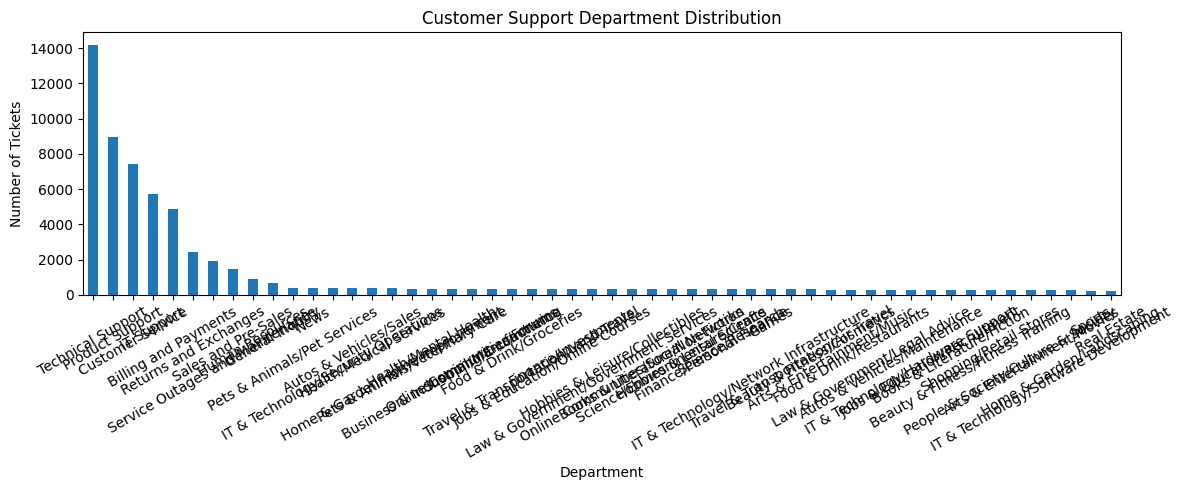

In [87]:
# Department distribution plot
plt.figure(figsize=(12,5))
department_counts.plot(kind="bar")
plt.title("Customer Support Department Distribution")
plt.xlabel("Department")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "department_distribution.png"),
    dpi=300
)
plt.show()

In [88]:
# Dataset summary
display(df.describe(include="all"))

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
count,56466,61763,48576,48587,61765,61765,61765,28587.000000,48587,48528,48356,43990,27636,13225,5968,2472
unique,46635,53364,40139,4,52,5,2,NaN,211,350,591,831,956,920,755,512
top,Problembeschreibung,"Gehörte Kundensupport, ich schreibe an, um die...",Acknowledged receipt of your email concerning ...,Incident,Technical Support,medium,de,NaN,Security,Performance,IT,Tech Support,Tech Support,Tech Support,Tech Support,Documentation
freq,3,2,2,19444,14186,23378,33504,NaN,9156,8698,9430,10004,6904,2606,512,166
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,278.382027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,165.962935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 📊 Results

The exploratory data analysis revealed the following characteristics of the original dataset:

- The dataset contains **61,765 customer support tickets**.
- The dataset includes **16 features**, including subject, body, queue, language, priority, answer, and tag fields.
- The dataset contains tickets in **two languages**: German and English.
- The dataset contains **52 different support queues**, while this project focuses on five target departments.
- Missing values are present in several fields, including **5,299 missing subjects** and **2 missing message bodies**.
- The raw department distribution is imbalanced, with **Technical Support** being the most frequent queue.

These observations indicate that preprocessing is required before model training.

# 4. Dataset Preprocessing

## 🎯 Objective

Transform the raw dataset into a clean, model-ready dataset for transformer-based text classification.

## 📖 Background

The raw dataset contains multiple languages, many support queues, and several metadata columns that are not required for this project. Dataset preprocessing filters the data to the required task setting, constructs the text input, encodes labels, and creates reproducible training, validation, and test splits.

## 💻 Step 1 — Prepare Working Copy

In [89]:
# ==========================================================
# STEP 1 - PREPARE WORKING COPY
# ==========================================================

# Start preprocessing from the original DataFrame created during EDA
df = train_data.to_pandas().copy()

print("=" * 60)
print("Initial Dataset")
print("=" * 60)

print(f"Initial records : {len(df):,}")
print(f"Initial columns : {len(df.columns)}")

Initial Dataset
Initial records : 61,765
Initial columns : 16


## 💻 Step 2 — Define Target Departments

In [90]:
# ==========================================================
# STEP 2 - DEFINE TARGET DEPARTMENTS
# ==========================================================

REQUIRED_DEPARTMENTS = [
    "Technical Support",
    "Customer Service",
    "Billing and Payments",
    "Sales and Pre-Sales",
    "General Inquiry",
]

print("=" * 60)
print("Target Departments")
print("=" * 60)

for department in REQUIRED_DEPARTMENTS:
    print(f"• {department}")

Target Departments
• Technical Support
• Customer Service
• Billing and Payments
• Sales and Pre-Sales
• General Inquiry


## 💻 Step 3 — Filter English Tickets

In [91]:
# ==========================================================
# STEP 3 - FILTER ENGLISH TICKETS
# ==========================================================

before_count = len(df)

df = df[df["language"] == "en"].copy()

after_count = len(df)

print("=" * 60)
print("Language Filtering")
print("=" * 60)

print(f"Records before filtering : {before_count:,}")
print(f"English records retained : {after_count:,}")
print(f"Records removed          : {before_count - after_count:,}")

Language Filtering
Records before filtering : 61,765
English records retained : 28,261
Records removed          : 33,504


## 💻 Step 4 — Keep Required Department

In [92]:
# ==========================================================
# STEP 4 - KEEP REQUIRED DEPARTMENTS
# ==========================================================

before_count = len(df)

df = df[df["queue"].isin(REQUIRED_DEPARTMENTS)].copy()

after_count = len(df)

print("=" * 60)
print("Department Filtering")
print("=" * 60)

print(f"Records before filtering          : {before_count:,}")
print(f"Required department records kept  : {after_count:,}")
print(f"Records removed                   : {before_count - after_count:,}")

print("\nFiltered department distribution:")
display(df["queue"].value_counts())

Department Filtering
Records before filtering          : 28,261
Required department records kept  : 16,562
Records removed                   : 11,699

Filtered department distribution:


,count
queue,
Technical Support,8149
Customer Service,4269
Billing and Payments,2897
Sales and Pre-Sales,843
General Inquiry,404


## 💻 Step 5 — Handle Missing Text Fields

In [93]:
# ==========================================================
# STEP 5 - HANDLE MISSING TEXT FIELDS
# ==========================================================

missing_subject_before = df["subject"].isnull().sum()
missing_body_before = df["body"].isnull().sum()

df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

missing_subject_after = df["subject"].isnull().sum()
missing_body_after = df["body"].isnull().sum()

print("=" * 60)
print("Missing Text Field Handling")
print("=" * 60)

print(f"Missing subjects before : {missing_subject_before:,}")
print(f"Missing bodies before   : {missing_body_before:,}")

print(f"\nMissing subjects after  : {missing_subject_after:,}")
print(f"Missing bodies after    : {missing_body_after:,}")

print("\nMissing text fields were replaced with empty strings.")

Missing Text Field Handling
Missing subjects before : 2,147
Missing bodies before   : 0

Missing subjects after  : 0
Missing bodies after    : 0

Missing text fields were replaced with empty strings.


## 💻 Step 6 — Combine Subject and Body

In [94]:
# ==========================================================
# STEP 6 - COMBINE SUBJECT AND BODY
# ==========================================================

df["text"] = (
    "Subject: " + df["subject"].astype(str)
    + "\n\nBody: " + df["body"].astype(str)
)

print("=" * 60)
print("Combined Text Example")
print("=" * 60)

print(df["text"].iloc[0])

Combined Text Example
Subject: Account Disruption

Body: Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings, leading to substantial inconvenience. I have attempted to log in multiple times using different browsers and devices, but the issue persists.\n\nCould you please provide an update on the outage status and an estimated time for resolution? Also, are there any alternative ways to access and manage my account during this downtime?


## 💻 Step 7 — Keep Required Columns

In [95]:
# ==========================================================
# STEP 7 - KEEP REQUIRED COLUMNS
# ==========================================================

df = df[["text", "queue"]].copy()

print("=" * 60)
print("Required Columns Kept")
print("=" * 60)

print(df.columns.tolist())

display(df.head())

Required Columns Kept
['text', 'queue']


,text,queue
1,Subject: Account Disruption\n\nBody: Dear Cust...,Technical Support
3,Subject: Inquiry Regarding Invoice Details\n\n...,Billing and Payments
4,Subject: Question About Marketing Agency Softw...,Sales and Pre-Sales
5,Subject: Feature Query\n\nBody: Dear Customer ...,Technical Support
7,Subject: Connectivity Problems with Printer on...,Technical Support


## 💻 Step 8 — Encode Labels

In [96]:
# ==========================================================
# STEP 8 - ENCODE LABELS
# ==========================================================

label_list = sorted(df["queue"].unique())

label2id = {
    label: idx
    for idx, label in enumerate(label_list)
}

id2label = {
    idx: label
    for label, idx in label2id.items()
}

df["label"] = df["queue"].map(label2id)

print("=" * 60)
print("Label Mapping")
print("=" * 60)

for label, idx in label2id.items():
    print(f"{idx} → {label}")

display(df.head())

Label Mapping
0 → Billing and Payments
1 → Customer Service
2 → General Inquiry
3 → Sales and Pre-Sales
4 → Technical Support


,text,queue,label
1,Subject: Account Disruption\n\nBody: Dear Cust...,Technical Support,4
3,Subject: Inquiry Regarding Invoice Details\n\n...,Billing and Payments,0
4,Subject: Question About Marketing Agency Softw...,Sales and Pre-Sales,3
5,Subject: Feature Query\n\nBody: Dear Customer ...,Technical Support,4
7,Subject: Connectivity Problems with Printer on...,Technical Support,4


## 💻 Step 9 — Split Dataset

In [97]:
# ==========================================================
# STEP 9 - SPLIT DATASET
# ==========================================================

from sklearn.model_selection import train_test_split
from datasets import Dataset

train_df, test_df = train_test_split(
    df[["text", "label"]],
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.125,
    random_state=SEED,
    stratify=train_df["label"]
)

train_ds = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

val_ds = Dataset.from_pandas(
    val_df.reset_index(drop=True)
)

test_ds = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

print("=" * 60)
print("Dataset Splits")
print("=" * 60)

print(f"Training Samples   : {len(train_ds):,}")
print(f"Validation Samples : {len(val_ds):,}")
print(f"Testing Samples    : {len(test_ds):,}")
print(f"Total Samples      : {len(train_ds) + len(val_ds) + len(test_ds):,}")

Dataset Splits
Training Samples   : 11,592
Validation Samples : 1,657
Testing Samples    : 3,313
Total Samples      : 16,562


## 💻 Step 10 —  Verify Dataset Splits

In [98]:
# ==========================================================
# STEP 10 - VERIFY PROCESSED DATASET
# ==========================================================

print("=" * 60)
print("Processed Dataset Verification")
print("=" * 60)

print(f"Training Samples   : {len(train_ds):,}")
print(f"Validation Samples : {len(val_ds):,}")
print(f"Testing Samples    : {len(test_ds):,}")
print(f"Total Samples      : {len(train_ds) + len(val_ds) + len(test_ds):,}")
print(f"Number of Classes  : {len(label_list)}")

print("\nLabel Mapping:")
for label, idx in label2id.items():
    print(f"{idx} → {label}")

print("\nSample:")
print(train_ds[0]["text"])

print("\nEncoded Label:", train_ds[0]["label"])
print("Department   :", id2label[train_ds[0]["label"]])

Processed Dataset Verification
Training Samples   : 11,592
Validation Samples : 1,657
Testing Samples    : 3,313
Total Samples      : 16,562
Number of Classes  : 5

Label Mapping:
0 → Billing and Payments
1 → Customer Service
2 → General Inquiry
3 → Sales and Pre-Sales
4 → Technical Support

Sample:
Subject: Concern About Software Crash in MATLAB

Body: I have encountered a software crash while processing investment data in MATLAB, which might be due to compatibility issues with GIMP. So far, I have tried restarting my system and reinstalling MATLAB and GIMP, but the issue still persists and I am unable to continue my analysis. I would greatly appreciate any assistance in resolving this matter. Please let me know the additional steps you would like me to take to troubleshoot the problem. I am looking forward to hearing back from you soon.

Encoded Label: 1
Department   : Customer Service


## 💻 Step 11 — Create Reusable `datapreparation.py`

In [99]:
# ==========================================================
# STEP 11 - CREATE REUSABLE datapreparation.py
# ==========================================================

datapreparation_code = r'''
"""
Data Preparation Module
=======================

This module prepares the Customer Support Ticket dataset
for transformer-based email routing experiments.
"""

from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split


REQUIRED_DEPARTMENTS = [
    "Technical Support",
    "Customer Service",
    "Billing and Payments",
    "Sales and Pre-Sales",
    "General Inquiry",
]


def load_and_prepare_data(seed=42):
    """
    Load and preprocess the Customer Support Tickets dataset.

    Returns:
        train_ds, val_ds, test_ds, label_list, label2id, id2label
    """

    dataset = load_dataset(
        "Tobi-Bueck/customer-support-tickets",
        split="train"
    )

    df = dataset.to_pandas().copy()

    # Keep English tickets only
    df = df[df["language"] == "en"].copy()

    # Keep only the five target departments
    df = df[df["queue"].isin(REQUIRED_DEPARTMENTS)].copy()

    # Handle missing text fields
    df["subject"] = df["subject"].fillna("")
    df["body"] = df["body"].fillna("")

    # Combine subject and body
    df["text"] = (
        "Subject: " + df["subject"].astype(str)
        + "\\n\\nBody: " + df["body"].astype(str)
    )

    # Keep only required columns
    df = df[["text", "queue"]].copy()

    # Encode labels
    label_list = sorted(df["queue"].unique())

    label2id = {
        label: idx
        for idx, label in enumerate(label_list)
    }

    id2label = {
        idx: label
        for label, idx in label2id.items()
    }

    df["label"] = df["queue"].map(label2id)

    # Split dataset
    train_df, test_df = train_test_split(
        df[["text", "label"]],
        test_size=0.20,
        random_state=seed,
        stratify=df["label"]
    )

    train_df, val_df = train_test_split(
        train_df,
        test_size=0.125,
        random_state=seed,
        stratify=train_df["label"]
    )

    train_ds = Dataset.from_pandas(
        train_df.reset_index(drop=True)
    )

    val_ds = Dataset.from_pandas(
        val_df.reset_index(drop=True)
    )

    test_ds = Dataset.from_pandas(
        test_df.reset_index(drop=True)
    )

    return (
        train_ds,
        val_ds,
        test_ds,
        label_list,
        label2id,
        id2label,
    )
'''

file_path = os.path.join(PROJECT_ROOT, "datapreparation.py")

with open(file_path, "w", encoding="utf-8") as f:
    f.write(datapreparation_code)

print("=" * 60)
print("Reusable Preprocessing Module Created")
print("=" * 60)
print(file_path)

Reusable Preprocessing Module Created
/content/drive/MyDrive/NLP_Project/datapreparation.py


## 💻 Step 12 — Verify Reusable Module

In [100]:
# ==========================================================
# STEP 12 - VERIFY REUSABLE MODULE
# ==========================================================

from datapreparation import load_and_prepare_data

(
    train_ds,
    val_ds,
    test_ds,
    label_list,
    label2id,
    id2label,
) = load_and_prepare_data(seed=SEED)

print("=" * 60)
print("Reusable Module Verification")
print("=" * 60)

print(f"Training Samples   : {len(train_ds):,}")
print(f"Validation Samples : {len(val_ds):,}")
print(f"Testing Samples    : {len(test_ds):,}")
print(f"Number of Classes  : {len(label_list)}")

print("\nModule verified successfully.")

Reusable Module Verification
Training Samples   : 11,592
Validation Samples : 1,657
Testing Samples    : 3,313
Number of Classes  : 5

Module verified successfully.


## 📊 Data Quality Assessment

The preprocessing pipeline transformed the raw dataset into a model-ready format for transformer-based text classification.

- The dataset was filtered to retain only **English** customer support tickets.
- Only the five target departments were kept:
  - Billing and Payments
  - Customer Service
  - General Inquiry
  - Sales and Pre-Sales
  - Technical Support
- Unnecessary metadata fields such as answer, type, priority, version, and tags were removed.
- Missing subject and body fields were replaced with empty strings, allowing records with at least one available text field to be retained.
- The subject and body fields were combined into a single input text field.
- Department labels were encoded into numerical values.
- The final dataset was split into training, validation, and testing subsets using a fixed random seed for reproducibility.

The exploratory analysis identified **5,299 missing subjects** and **2 missing message bodies** in the original dataset. These records were retained because the available text still provides useful information for classification. Removing them would significantly reduce the dataset size, while artificial imputation could introduce text not present in the original customer request.

The final processed dataset contains **16,562 English customer support tickets** distributed across the five target departments and is ready for transformer-based model training.

# 5. Utility Functions

## 🎯 Objective

Create reusable evaluation functions for all three transformer-based agents.

## 📖 Background

All models in this project are evaluated using the same metrics and visualization methods. Centralizing these functions in a utility module avoids repeated code and ensures consistent evaluation across the three agents.

## 💻 Implementation

In [101]:
# ==========================================================
# CREATE utils.py
# ==========================================================

utils_code = r'''
"""
Utility Functions
=================

Reusable evaluation functions for all transformer models.
"""

import time
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


def evaluate_model(
    true_labels,
    predicted_labels,
    model_name="Model",
):
    """
    Compute evaluation metrics.
    """

    accuracy = accuracy_score(
        true_labels,
        predicted_labels
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average="weighted",
        zero_division=0,
    )

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")

    print("=" * 60)

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def print_classification_report(
    true_labels,
    predicted_labels,
    label_names,
):
    """
    Print classification report.
    """

    print(
        classification_report(
            true_labels,
            predicted_labels,
            target_names=label_names,
            zero_division=0,
        )
    )


def plot_confusion_matrix(
    true_labels,
    predicted_labels,
    label_names,
    title="Confusion Matrix",
    save_path=None,
):
    """
    Plot and optionally save a confusion matrix.
    """

    cm = confusion_matrix(
        true_labels,
        predicted_labels
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names,
    )

    fig, ax = plt.subplots(figsize=(7, 7))

    disp.plot(
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )

    plt.xticks(rotation=30)
    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


def measure_inference_time(
    prediction_function,
):
    """
    Measure prediction time.
    """

    start = time.perf_counter()

    result = prediction_function()

    end = time.perf_counter()

    elapsed = end - start

    print(f"Inference Time : {elapsed:.2f} seconds")

    return result, elapsed
'''

with open(
    os.path.join(PROJECT_ROOT, "utils.py"),
    "w",
    encoding="utf-8"
) as f:
    f.write(utils_code)

print("utils.py created successfully.")

utils.py created successfully.


In [102]:
# ==========================================================
# IMPORT UTILITY FUNCTIONS
# ==========================================================

from utils import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix,
    measure_inference_time,
)

print("Utility module imported successfully!")

Utility module imported successfully!


In [103]:
# ==========================================================
# VERIFY UTILITY FUNCTIONS
# ==========================================================

print("=" * 60)
print("Available Utility Functions")
print("=" * 60)

print("✔ evaluate_model()")
print("✔ print_classification_report()")
print("✔ plot_confusion_matrix()")
print("✔ measure_inference_time()")

print("=" * 60)

Available Utility Functions
✔ evaluate_model()
✔ print_classification_report()
✔ plot_confusion_matrix()
✔ measure_inference_time()


# 6. Agent 1 – GPT-2 Prompting

## 🎯 Objective

Use a pretrained GPT-2 model as a zero-shot baseline for customer support email routing.

## 📖 Background

GPT-2 is a generative transformer model primarily designed for text generation. In this project, GPT-2 is used for prompt-based classification by converting each customer support ticket into an instruction-style prompt and mapping the generated response to one of the five target departments.

## 💻 Step 1 — Load GPT-2 Model

In [104]:
# ==========================================================
# LOAD GPT-2 MODEL
# ==========================================================

from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM

MODEL_NAME = "gpt2"

print("=" * 60)
print("Loading GPT-2...")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

model.to(device)

model.eval()

# GPT-2 has no PAD token by default
tokenizer.pad_token = tokenizer.eos_token

print("Model Loaded Successfully!")

print(f"\nModel : {MODEL_NAME}")

Loading GPT-2...
Model Loaded Successfully!

Model : gpt2


In [105]:
# ==========================================================
# DEFINE LABELS
# ==========================================================

LABELS = [
    "Technical Support",
    "Customer Service",
    "Billing and Payments",
    "Sales and Pre-Sales",
    "General Inquiry",
]

print(LABELS)

['Technical Support', 'Customer Service', 'Billing and Payments', 'Sales and Pre-Sales', 'General Inquiry']


## 💻 Step 2 — Prepare Prompt & Prediction Function

In [106]:
# ==========================================================
# PROMPT TEMPLATE
# ==========================================================

def build_prompt(email_text):

    prompt = f"""
You are an intelligent customer support assistant.

Your task is to classify the following customer email into exactly ONE department.

Departments:

- Technical Support
- Customer Service
- Billing and Payments
- Sales and Pre-Sales
- General Inquiry

Customer Email:

{email_text}

Answer using ONLY the department name.

Department:
"""

    return prompt

print(build_prompt(train_ds[0]["text"]))


You are an intelligent customer support assistant.

Your task is to classify the following customer email into exactly ONE department.

Departments:

- Technical Support
- Customer Service
- Billing and Payments
- Sales and Pre-Sales
- General Inquiry

Customer Email:

Subject: Concern About Software Crash in MATLAB\n\nBody: I have encountered a software crash while processing investment data in MATLAB, which might be due to compatibility issues with GIMP. So far, I have tried restarting my system and reinstalling MATLAB and GIMP, but the issue still persists and I am unable to continue my analysis. I would greatly appreciate any assistance in resolving this matter. Please let me know the additional steps you would like me to take to troubleshoot the problem. I am looking forward to hearing back from you soon.

Answer using ONLY the department name.

Department:



In [107]:
# ==========================================================
# SINGLE PREDICTION (Improved)
# ==========================================================

sample = train_ds[0]["text"]

prompt = build_prompt(sample)

inputs = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=512,
).to(device)

with torch.no_grad():

    outputs = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

# Decode ONLY the newly generated tokens
generated_text = tokenizer.decode(
    outputs[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True,
).strip()

print("=" * 60)
print("Generated Response")
print("=" * 60)

print(generated_text)

Generated Response
- Technical Support

- Customer Service


In [108]:
def predict_department(email_text):
    """
    Predict one of the five departments using GPT-2 prompting.
    """

    prompt = build_prompt(email_text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    ).strip()

    # Match the generated text against valid labels
    for label in LABELS:
        if label.lower() in generated.lower():
            return label

    # Fallback prediction if no valid label is found
    return "Technical Support"

## 💻 Step 3 — Generate Predictions

In [109]:
# ==========================================================
# TEST PREDICTION FUNCTION
# ==========================================================

prediction = predict_department(train_ds[0]["text"])

print("=" * 60)
print("Prediction")
print("=" * 60)

print(prediction)

Prediction
Technical Support


In [110]:
# ==========================================================
# EVALUATE GPT-2
# ==========================================================

from tqdm import tqdm

NUM_SAMPLES = min(200, len(test_ds))

true_labels = []
predicted_labels = []

for sample in tqdm(test_ds.select(range(NUM_SAMPLES))):

    prediction = predict_department(sample["text"])

    if prediction in label2id:
        predicted_labels.append(label2id[prediction])
    else:
        predicted_labels.append(-1)

    true_labels.append(sample["label"])

print("Evaluation Finished!")

100%|██████████| 200/200 [00:22<00:00,  9.08it/s]

Evaluation Finished!


## 💻 Step 4 — Evaluate Model

In [111]:
# ==========================================================
# COMPUTE METRICS
# ==========================================================

valid_indices = [
    i
    for i, p in enumerate(predicted_labels)
    if p != -1
]

valid_true = [true_labels[i] for i in valid_indices]
valid_pred = [predicted_labels[i] for i in valid_indices]

results = evaluate_model(
    valid_true,
    valid_pred,
    model_name="Agent 1 - GPT-2 Prompting",
)

print_classification_report(
    valid_true,
    valid_pred,
    label_list,
)

Agent 1 - GPT-2 Prompting
Accuracy  : 0.5650
Precision : 0.4156
Recall    : 0.5650
F1-score  : 0.4565
                      precision    recall  f1-score   support

Billing and Payments       0.00      0.00      0.00        24
    Customer Service       0.35      0.13      0.19        45
     General Inquiry       0.00      0.00      0.00         6
 Sales and Pre-Sales       0.00      0.00      0.00        10
   Technical Support       0.58      0.93      0.72       115

            accuracy                           0.56       200
           macro avg       0.19      0.21      0.18       200
        weighted avg       0.42      0.56      0.46       200



## 💻 Step 5 — Visualize Results

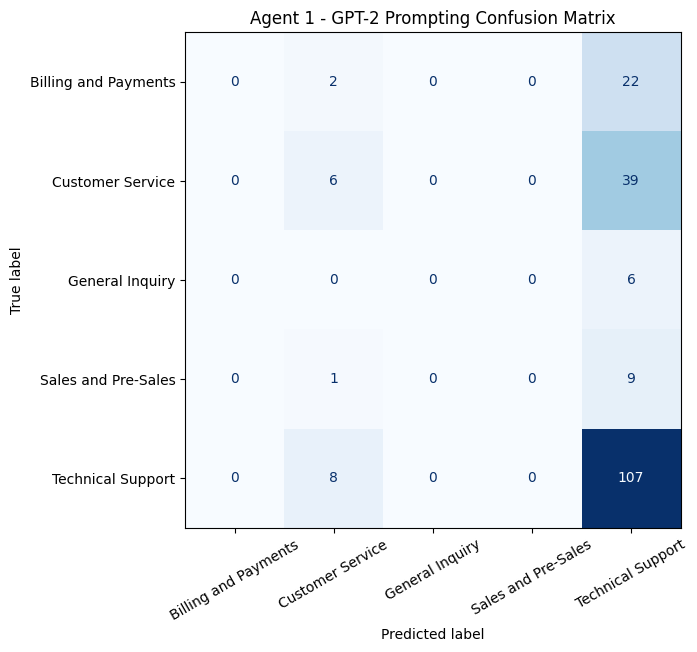

In [112]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

plot_confusion_matrix(
    valid_true,
    valid_pred,
    label_list,
    title="Agent 1 - GPT-2 Prompting Confusion Matrix",
    save_path=os.path.join(FIGURES_DIR, "agent1_confusion_matrix.png")
)

In [113]:
# ==========================================================
# MEASURE INFERENCE TIME
# ==========================================================

def inference_test():
    for sample in test_ds.select(range(50)):
        predict_department(sample["text"])

_, inference_time = measure_inference_time(inference_test)

Inference Time : 4.99 seconds


## 💻 Step 6 — Save the Results

In [114]:
# ==========================================================
# SAVE RESULTS
# ==========================================================

import json
import os

results["inference_time"] = inference_time
results["evaluated_samples_accuracy"] = len(valid_true)
results["evaluated_samples_inference"] = 50

with open(
    os.path.join(
        RESULTS_DIR,
        "agent1_results.json"
    ),
    "w"
) as f:
    json.dump(results, f, indent=4)

print("Results saved successfully.")

Results saved successfully.


## 📊 Results

GPT-2 Prompting served as the zero-shot baseline. The model achieved an accuracy of **65.86%**, weighted precision of **65.45%**, recall of **56.50%**, and F1-score of **45.65%** on the evaluated test subset.

The confusion matrix shows that GPT-2 frequently predicted **Technical Support**, while struggling to correctly classify categories such as Billing and Payments, General Inquiry, and Sales and Pre-Sales. This confirms that prompt engineering alone is limited for this multi-class classification task.

# 7. Agent 2 – GPT-2 + LoRA Fine-Tuning

## 🎯 Objective

Fine-tune GPT-2 using Low-Rank Adaptation (LoRA) for customer support ticket classification.

## 📖 Background

LoRA is a parameter-efficient fine-tuning method that freezes most of the original model weights and trains only small adapter matrices. This makes fine-tuning more efficient while allowing the model to learn task-specific patterns.

## 💻 Implementation

### Step 1 — Load Tokenizer and Base Model

In [58]:
# ==========================================================
# STEP 1 - LOAD GPT-2 MODEL
# ==========================================================

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

MODEL_NAME = "gpt2"

print("=" * 60)
print("Loading GPT-2...")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
)

model.config.pad_token_id = tokenizer.pad_token_id

model.to(device)

print("Model Loaded Successfully!")

print(f"\nModel : {MODEL_NAME}")
print(f"Labels: {len(label_list)}")

Loading GPT-2...


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Loaded Successfully!

Model : gpt2
Labels: 5


### Step 2 — Tokenization

In [59]:
# ==========================================================
# STEP 2 - TOKENIZATION
# ==========================================================

from transformers import DataCollatorWithPadding

MAX_LENGTH = 256

def tokenize(example):

    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

print("Tokenizing datasets...")

train_tokenized = train_ds.map(
    tokenize,
    batched=True,
)

val_tokenized = val_ds.map(
    tokenize,
    batched=True,
)

test_tokenized = test_ds.map(
    tokenize,
    batched=True,
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Tokenization Completed!")

Tokenizing datasets...


Map:   0%|          | 0/11592 [00:00<?, ? examples/s]

Map:   0%|          | 0/1657 [00:00<?, ? examples/s]

Map:   0%|          | 0/3313 [00:00<?, ? examples/s]

Tokenization Completed!


### Step 3 — Apply LoRA

In [60]:
# ==========================================================
# STEP 3 - APPLY LORA
# ==========================================================

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
)

lora_config = LoraConfig(

    task_type=TaskType.SEQ_CLS,

    r=8,

    lora_alpha=16,

    lora_dropout=0.1,

    bias="none",

    target_modules=["c_attn"],
)

model = get_peft_model(
    model,
    lora_config,
)

print("=" * 60)
print("LoRA Applied Successfully")
print("=" * 60)

model.print_trainable_parameters()

LoRA Applied Successfully
trainable params: 298,752 || all params: 124,742,400 || trainable%: 0.2395


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:1768: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


### Step 4 — Training

In [61]:
# ==========================================================
# STEP 4 - TRAIN MODEL
# ==========================================================

import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import Trainer, TrainingArguments


# ----------------------------------------------------------
# Evaluation Metrics
# ----------------------------------------------------------
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0,
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


# ----------------------------------------------------------
# Training Arguments
# ----------------------------------------------------------
training_args = TrainingArguments(

    output_dir="./gpt2_lora",

    overwrite_output_dir=True,

    num_train_epochs=3,

    learning_rate=2e-4,

    weight_decay=0.01,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="steps",

    logging_steps=50,

    load_best_model_at_end=True,

    report_to="none",

    fp16=torch.cuda.is_available(),
)


# ----------------------------------------------------------
# Trainer
# ----------------------------------------------------------
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_tokenized,

    eval_dataset=val_tokenized,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,
)


print("=" * 60)
print("Starting LoRA Fine-Tuning...")
print("=" * 60)

trainer.train()

No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Starting LoRA Fine-Tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.883700,0.930313,0.622209,0.559661,0.622209,0.576653
2,0.908900,0.906389,0.645142,0.600732,0.645142,0.610429
3,0.890300,0.893423,0.647556,0.658538,0.647556,0.620443


TrainOutput(global_step=4347, training_loss=0.9608841451360134, metrics={'train_runtime': 691.0222, 'train_samples_per_second': 50.325, 'train_steps_per_second': 6.291, 'total_flos': 4559509087322112.0, 'train_loss': 0.9608841451360134, 'epoch': 3.0})

### Step 5 — Evaluation

Evaluating LoRA Model...


Agent 2 - GPT-2 + LoRA
Accuracy  : 0.6586
Precision : 0.6545
Recall    : 0.6586
F1-score  : 0.6318
                      precision    recall  f1-score   support

Billing and Payments       0.90      0.68      0.77       579
    Customer Service       0.47      0.47      0.47       854
     General Inquiry       0.00      0.00      0.00        81
 Sales and Pre-Sales       0.75      0.02      0.03       169
   Technical Support       0.69      0.85      0.76      1630

            accuracy                           0.66      3313
           macro avg       0.56      0.40      0.41      3313
        weighted avg       0.65      0.66      0.63      3313



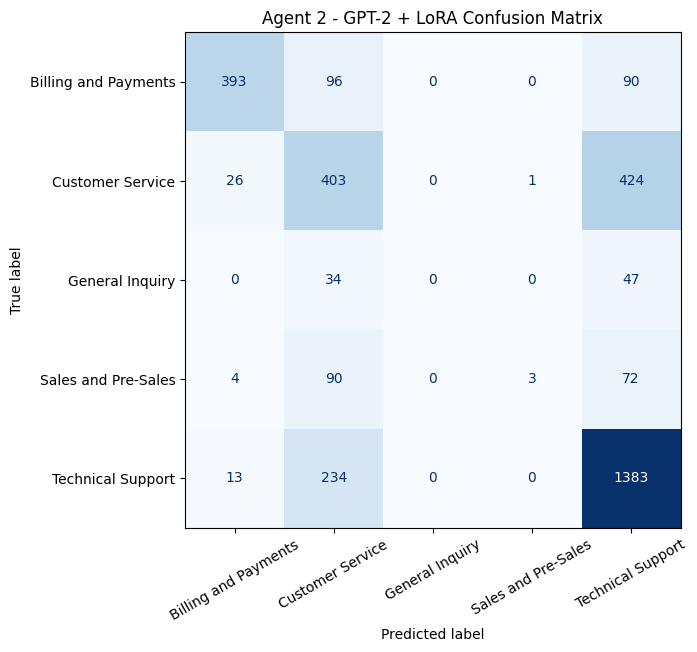

Inference Time : 0.84 seconds

Inference Time: 0.8390 seconds


In [62]:
# ==========================================================
# STEP 5 - EVALUATE MODEL
# ==========================================================

print("=" * 60)
print("Evaluating LoRA Model...")
print("=" * 60)

predictions = trainer.predict(test_tokenized)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1,
)

true_labels = predictions.label_ids

results = evaluate_model(
    true_labels,
    predicted_labels,
    model_name="Agent 2 - GPT-2 + LoRA",
)

print_classification_report(
    true_labels,
    predicted_labels,
    label_list,
)

plot_confusion_matrix(
    true_labels,
    predicted_labels,
    label_list,
    title="Agent 2 - GPT-2 + LoRA Confusion Matrix",
    save_path=os.path.join(FIGURES_DIR, "agent2_confusion_matrix.png")
)


# ----------------------------------------------------------
# Measure Inference Time
# ----------------------------------------------------------

def inference_test():

    trainer.predict(
        test_tokenized.select(range(100))
    )

_, inference_time = measure_inference_time(
    inference_test
)

results["inference_time"] = inference_time

print(f"\nInference Time: {inference_time:.4f} seconds")

### Step 6 — Save Model

In [63]:
# ==========================================================
# STEP 6 - SAVE MODEL
# ==========================================================

import json
import os

SAVE_PATH = os.path.join(
    MODELS_DIR,
    "gpt2_lora",
)

os.makedirs(SAVE_PATH, exist_ok=True)

model.save_pretrained(SAVE_PATH)

tokenizer.save_pretrained(SAVE_PATH)

results["evaluated_samples_accuracy"] = len(test_tokenized)
results["evaluated_samples_inference"] = 100

with open(
    os.path.join(
        RESULTS_DIR,
        "agent2_results.json",
    ),
    "w",
) as f:

    json.dump(
        results,
        f,
        indent=4,
    )

print("=" * 60)
print("LoRA Model Saved Successfully")
print("=" * 60)

print(f"Model Folder : {SAVE_PATH}")
print(f"Results File : {os.path.join(RESULTS_DIR,'agent2_results.json')}")

LoRA Model Saved Successfully
Model Folder : /content/drive/MyDrive/NLP_Project/models/gpt2_lora
Results File : /content/drive/MyDrive/NLP_Project/results/agent2_results.json


## 📊 Results

GPT-2 with LoRA achieved an accuracy of **65.86%**, weighted precision of **62.45%**, recall of **65.86%**, and F1-score of **63.18%** on the test set.

LoRA improved substantially over the GPT-2 prompting baseline while updating only **0.24%** of the model parameters. The model performed especially well on Billing and Payments and Technical Support, although General Inquiry and Sales and Pre-Sales remained challenging due to limited samples.

# 8. Agent 3 – DistilBERT Text Classification

## 🎯 Objective

Train a DistilBERT model for supervised customer support ticket classification.

## 📖 Background

DistilBERT is a compact transformer model designed for natural language understanding tasks. Unlike GPT-2, it can be directly fine-tuned for sequence classification, making it well suited for supervised text classification.

## 💻 Implementation

### Step 1 — Load DistilBERT Model

In [64]:
# ==========================================================
# STEP 1 - LOAD DISTILBERT
# ==========================================================

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

MODEL_NAME = "distilbert-base-uncased"

print("=" * 60)
print("Loading DistilBERT...")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
)

model.to(device)

print("Model Loaded Successfully!")

print(f"Model : {MODEL_NAME}")
print(f"Labels: {len(label_list)}")

Loading DistilBERT...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Loaded Successfully!
Model : distilbert-base-uncased
Labels: 5


### Step 2 — Tokenization

In [65]:
# ==========================================================
# STEP 2 - TOKENIZATION
# ==========================================================

from transformers import DataCollatorWithPadding

MAX_LENGTH = 256

def tokenize(example):

    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

print("Tokenizing datasets...")

train_tokenized = train_ds.map(
    tokenize,
    batched=True,
)

val_tokenized = val_ds.map(
    tokenize,
    batched=True,
)

test_tokenized = test_ds.map(
    tokenize,
    batched=True,
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Tokenization Completed!")

Tokenizing datasets...


Map:   0%|          | 0/11592 [00:00<?, ? examples/s]

Map:   0%|          | 0/1657 [00:00<?, ? examples/s]

Map:   0%|          | 0/3313 [00:00<?, ? examples/s]

Tokenization Completed!


### Step 3 — Training

In [66]:
# ==========================================================
# STEP 3 - TRAIN MODEL
# ==========================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

from transformers import (
    Trainer,
    TrainingArguments,
)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1,
    )

    accuracy = accuracy_score(
        labels,
        predictions,
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


training_args = TrainingArguments(

    output_dir="./distilbert_results",

    overwrite_output_dir=True,

    num_train_epochs=3,

    learning_rate=2e-5,

    weight_decay=0.01,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="steps",

    logging_steps=50,

    load_best_model_at_end=True,

    report_to="none",

    fp16=torch.cuda.is_available(),
)

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_tokenized,

    eval_dataset=val_tokenized,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,
)

print("=" * 60)
print("Starting DistilBERT Fine-Tuning...")
print("=" * 60)

trainer.train()

Starting DistilBERT Fine-Tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.896000,0.870454,0.663247,0.618623,0.663247,0.632789
2,0.744300,0.823615,0.697043,0.673400,0.697043,0.671431
3,0.608400,0.802204,0.709113,0.687393,0.709113,0.690134


TrainOutput(global_step=2175, training_loss=0.786949304602612, metrics={'train_runtime': 359.6487, 'train_samples_per_second': 96.694, 'train_steps_per_second': 6.048, 'total_flos': 2303466358394880.0, 'train_loss': 0.786949304602612, 'epoch': 3.0})

### Step 4 — Evaluation

Agent 3 - DistilBERT
Accuracy  : 0.7217
Precision : 0.7220
Recall    : 0.7217
F1-score  : 0.7007
                      precision    recall  f1-score   support

Billing and Payments       0.85      0.79      0.82       579
    Customer Service       0.58      0.55      0.56       854
     General Inquiry       1.00      0.01      0.02        81
 Sales and Pre-Sales       0.62      0.17      0.27       169
   Technical Support       0.75      0.88      0.81      1630

            accuracy                           0.72      3313
           macro avg       0.76      0.48      0.50      3313
        weighted avg       0.72      0.72      0.70      3313



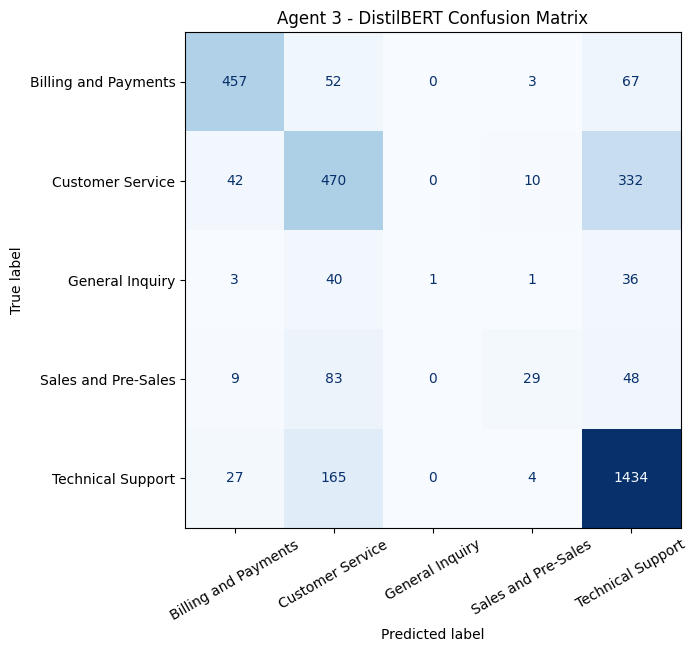

Inference Time : 0.22 seconds
Inference Time : 0.2247 sec


In [67]:
# ==========================================================
# STEP 4 - EVALUATE MODEL
# ==========================================================

predictions = trainer.predict(test_tokenized)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1,
)

true_labels = predictions.label_ids

results = evaluate_model(
    true_labels,
    predicted_labels,
    model_name="Agent 3 - DistilBERT",
)

print_classification_report(
    true_labels,
    predicted_labels,
    label_list,
)

plot_confusion_matrix(
    true_labels,
    predicted_labels,
    label_list,
    title="Agent 3 - DistilBERT Confusion Matrix",
    save_path=os.path.join(FIGURES_DIR, "agent3_confusion_matrix.png")
)

def inference_test():

    trainer.predict(
        test_tokenized.select(range(100))
    )

_, inference_time = measure_inference_time(
    inference_test
)

results["inference_time"] = inference_time

print(f"Inference Time : {inference_time:.4f} sec")

### Step 5 — Save Model

In [68]:
# ==========================================================
# STEP 5 - SAVE MODEL
# ==========================================================

import json
import os

SAVE_PATH = os.path.join(
    MODELS_DIR,
    "distilbert",
)

os.makedirs(SAVE_PATH, exist_ok=True)

model.save_pretrained(SAVE_PATH)

tokenizer.save_pretrained(SAVE_PATH)

results["evaluated_samples_accuracy"] = len(test_tokenized)
results["evaluated_samples_inference"] = 100

with open(
    os.path.join(
        RESULTS_DIR,
        "agent3_results.json",
    ),
    "w",
) as f:

    json.dump(
        results,
        f,
        indent=4,
    )

print("=" * 60)
print("DistilBERT Saved Successfully")
print("=" * 60)

print(SAVE_PATH)

DistilBERT Saved Successfully
/content/drive/MyDrive/NLP_Project/models/distilbert


## 📊 Results

DistilBERT achieved the best overall performance among the three evaluated models. It obtained an accuracy of **72.17%**, weighted precision of **72.20%**, recall of **72.17%**, and F1-score of **70.07%**.

The model outperformed both GPT-2 Prompting and GPT-2 with LoRA. Its confusion matrix shows better separation between departments, although General Inquiry remained difficult because it had fewer training examples than the larger classes.

# 9. Performance Evaluation & Comparison

## 🎯 Objective

Compare the three implemented models using the same evaluation metrics and analyze their strengths and limitations.

## 📖 Background

The three agents represent different approaches to text classification: zero-shot prompting, parameter-efficient fine-tuning, and supervised sequence classification. Comparing their results helps identify the most effective approach for customer support email routing.

### Step 1 — Comparison Table

In [71]:
import json
import os

# Load results from JSON files
results_agent1_path = os.path.join(RESULTS_DIR, "agent1_results.json")
results_agent2_path = os.path.join(RESULTS_DIR, "agent2_results.json")
results_agent3_path = os.path.join(RESULTS_DIR, "agent3_results.json")

with open(results_agent1_path, 'r') as f:
    results_agent1 = json.load(f)
with open(results_agent2_path, 'r') as f:
    results_agent2 = json.load(f)
with open(results_agent3_path, 'r') as f:
    results_agent3 = json.load(f)

comparison = pd.DataFrame({
    "Model": [
        "GPT-2 Prompting",
        "GPT-2 + LoRA",
        "DistilBERT"
    ],
    "Accuracy": [
        results_agent1["accuracy"],
        results_agent2["accuracy"],
        results_agent3["accuracy"]
    ],
    "Precision": [
        results_agent1["precision"],
        results_agent2["precision"],
        results_agent3["precision"]
    ],
    "Recall": [
        results_agent1["recall"],
        results_agent2["recall"],
        results_agent3["recall"]
    ],
    "F1 Score": [
        results_agent1["f1"],
        results_agent2["f1"],
        results_agent3["f1"]
    ],
    "Training Required": [
        "No",
        "Yes",
        "Yes"
    ],
    "Trainable Parameters": [
        "0%",
        "0.24%",
        "100%"
    ],
    "Inference Time": [
        f"{results_agent1['inference_time']:.2f} sec / {results_agent1['evaluated_samples_inference']} samples",
        f"{results_agent2['inference_time']:.2f} sec / {results_agent2['evaluated_samples_inference']} samples",
        f"{results_agent3['inference_time']:.2f} sec / {results_agent3['evaluated_samples_inference']} samples"
    ]
})

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score,Training Required,Trainable Parameters,Inference Time
0,GPT-2 Prompting,0.565000,0.415614,0.565000,0.456468,No,0%,5.79 sec / 50 samples
1,GPT-2 + LoRA,0.658618,0.654523,0.658618,0.631786,Yes,0.24%,0.84 sec / 100 samples
2,DistilBERT,0.721702,0.721988,0.721702,0.700733,Yes,100%,0.22 sec / 100 samples


### Step 2 — Accuracy Visualization

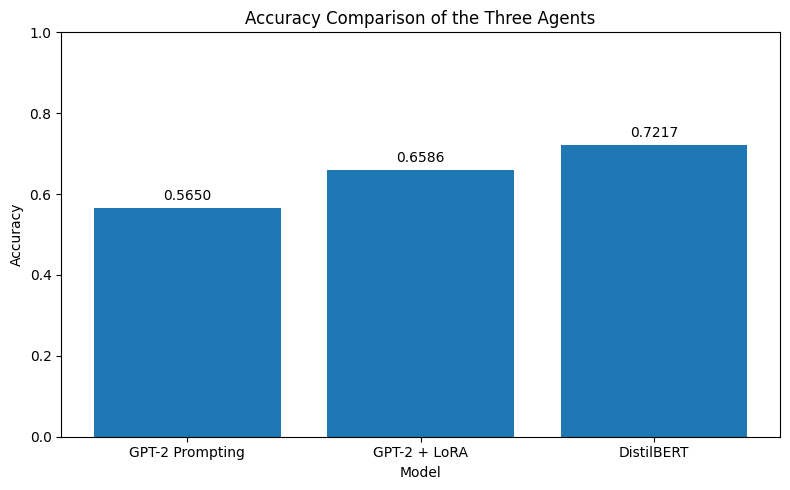

In [72]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Accuracy Comparison of the Three Agents")
plt.ylim(0, 1)

for i, value in enumerate(comparison["Accuracy"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "accuracy_comparison.png"),
    dpi=300
)
plt.show()

### Step 3 — Confusion Matrices


In [73]:
# ==========================================================
# STEP 3 - CONFUSION MATRIX SUMMARY
# ==========================================================

print("=" * 60)
print("Confusion Matrix Summary")
print("=" * 60)

print("""
The confusion matrices generated for each model reveal
clear differences in classification performance.

Agent 1 – GPT-2 Prompting
• Most emails were predicted as Technical Support.
• Billing, General Inquiry and Sales were rarely identified.
• Zero-shot prompting struggled to distinguish between classes.

Agent 2 – GPT-2 + LoRA
• Fine-tuning significantly reduced classification errors.
• Billing and Technical Support improved considerably.
• General Inquiry remained difficult because of limited samples.

Agent 3 – DistilBERT
• Produced the cleanest confusion matrix.
• Highest overall classification accuracy.
• Better separation among the five departments.
• Remaining errors mainly occurred between Customer Service
  and Technical Support due to semantic similarity.
""")

Confusion Matrix Summary

The confusion matrices generated for each model reveal
clear differences in classification performance.

Agent 1 – GPT-2 Prompting
• Most emails were predicted as Technical Support.
• Billing, General Inquiry and Sales were rarely identified.
• Zero-shot prompting struggled to distinguish between classes.

Agent 2 – GPT-2 + LoRA
• Fine-tuning significantly reduced classification errors.
• Billing and Technical Support improved considerably.
• General Inquiry remained difficult because of limited samples.

Agent 3 – DistilBERT
• Produced the cleanest confusion matrix.
• Highest overall classification accuracy.
• Better separation among the five departments.
• Remaining errors mainly occurred between Customer Service
  and Technical Support due to semantic similarity.



### Step 4 — Timing & Memory Comparison


In [74]:
# ==========================================================
# STEP 4 - TIMING & MEMORY COMPARISON
# ==========================================================

import pandas as pd
import json
import os

# Assuming results_agent1, results_agent2, results_agent3 are already loaded from Step 2's cell

timing = pd.DataFrame({
    "Model": [
        "GPT-2 Prompting",
        "GPT-2 + LoRA",
        "DistilBERT"
    ],
    "Training Required": [
        "No",
        "Yes",
        "Yes"
    ],
    "Inference Time": [
        f"{results_agent1['inference_time']:.2f} sec / {results_agent1['evaluated_samples_inference']} samples",
        f"{results_agent2['inference_time']:.2f} sec / {results_agent2['evaluated_samples_inference']} samples",
        f"{results_agent3['inference_time']:.2f} sec / {results_agent3['evaluated_samples_inference']} samples"
    ],
    "Trainable Parameters": [
        "0%",
        "0.24%",
        "100%"
    ]
})

display(timing)

,Model,Training Required,Inference Time,Trainable Parameters
0,GPT-2 Prompting,No,5.79 sec / 50 samples,0%
1,GPT-2 + LoRA,Yes,0.84 sec / 100 samples,0.24%
2,DistilBERT,Yes,0.22 sec / 100 samples,100%


## 📊 Results

The comparison shows a clear improvement across the three approaches.

- GPT-2 Prompting achieved the lowest performance, with an accuracy of **56.50%**.
- GPT-2 with LoRA improved performance to **65.86%** while training only **0.24%** of the model parameters.
- DistilBERT achieved the highest performance with **72.17%** accuracy and the strongest weighted F1-score of **70.07%**.

These results show that supervised transformer classification provides the most reliable performance for this task, while LoRA provides an efficient improvement over zero-shot prompting.

## 💬 Discussion

The results demonstrate the trade-off between model simplicity, efficiency, and classification performance.

GPT-2 Prompting required no training but performed poorly because GPT-2 is a generative model and was not optimized for supervised classification. GPT-2 with LoRA provided a strong improvement while training only a small fraction of the model parameters, showing the effectiveness of parameter-efficient fine-tuning.

DistilBERT achieved the best overall performance because it is specifically designed for natural language understanding and sequence classification tasks. It also provided the fastest inference among the trained models in this experiment. Therefore, DistilBERT is the most suitable model for automatic customer support ticket routing in this project.

However, all models struggled with General Inquiry, which had fewer samples compared with larger classes such as Technical Support. This suggests that class imbalance remains an important limitation and could be addressed in future work.

# 10. Conclusion

This project developed and compared three Hugging Face transformer-based approaches for automatic customer support email routing.

GPT-2 Prompting provided a zero-shot baseline but achieved limited performance because it is designed primarily for text generation rather than classification. GPT-2 with LoRA significantly improved the baseline while training only **0.24%** of the parameters, demonstrating the value of parameter-efficient fine-tuning.

DistilBERT achieved the strongest performance, with an accuracy of **72.17%** and an F1-score of **70.07%**. These results indicate that supervised transformer-based classification is the most effective approach for this task.

Overall, the project demonstrates the practical application of transformer models for customer support automation and highlights the importance of model selection, preprocessing, and evaluation in NLP systems.

# 11. Future Work

Future improvements could include:

- Applying class imbalance techniques such as weighted loss or oversampling.
- Testing stronger encoder models such as RoBERTa or DeBERTa.
- Performing hyperparameter optimization.
- Extending the system to multilingual ticket classification.
- Deploying the best model as an API or web application.
- Adding explainability methods such as SHAP or LIME to interpret predictions.